In [1]:
from qfi import *

from numpy import array, arange, zeros, ones, concatenate, linspace
import pickle

from matplotlib import pyplot as plt
plt.rcParams['font.family']='serif'
plt.rcParams['axes.unicode_minus']=True
plt.rcParams.update({'font.size': 20, 'text.latex.preamble': r'\usepackage{amsfonts, amsmath}', 'text.usetex': True})

In [2]:
from multiprocess import Pool
from itertools import repeat
from numpy import array

In [3]:
def qaoa_vec_der_beta(pars, ind, n, x_list, H_diag, state_ini):
    statevector_der = copy(state_ini)
    p = int(len(pars)/2)
    for j in range(p):
        k = 2*j
        statevector_der = apply_gamma(H_diag, pars[k], statevector_der)
        if j == ind:
            statevector_der = -1j*apply_Hx(n, x_list, statevector_der)
        statevector_der = apply_beta(n, x_list, pars[k + 1], statevector_der)
    return statevector_der

def qaoa_vec_der_gamma(pars, ind, n, x_list, H_diag, state_ini):
    statevector_der = copy(state_ini)
    p = int(len(pars)/2)
    for j in range(p):
        k = 2*j
        statevector_der = apply_gamma(H_diag, pars[k], statevector_der)
        if j == ind:
            statevector_der = -1j*apply_H(H_diag, statevector_der)
        statevector_der = apply_beta(n, x_list, pars[k + 1], statevector_der)
    return statevector_der

def jac(x):
    statevector = qaoa_vec(x, n, x_list, H_diag, state_ini)
    p = int(len(x)/2)
    gradient = zeros(2*p)
    for k in range(p):
        gradient[2*k] = vdot(qaoa_vec_der_gamma(x, k, n, x_list, H_diag, state_ini), H_diag*statevector).real
        gradient[2*k + 1] = vdot(qaoa_vec_der_beta(x, k, n, x_list, H_diag, state_ini), H_diag*statevector).real
    return 2*gradient

def fun(x, n, x_list, H_diag, state_ini):
    statevector = qaoa_vec(x, n, x_list, H_diag, state_ini)
    f = vdot(statevector, H_diag*statevector).real
    return f

In [4]:
def gradient_gamma_0(pars, n, x_list, H_diag, state_ini):
    statevector = qaoa_vec(pars, n, x_list, H_diag, state_ini)
    statevector_der_gamma_0 = qaoa_vec_der_gamma(pars, 0, n, x_list, H_diag, state_ini)
    return 2*vdot(statevector_der_gamma_0, H_diag*statevector).real

# Variance of the gradient component

In [9]:
n_list = [5, 6, 7, 8, 9, 10]
# n_list = [4, 5]

n_instances = 50
n_runs = 100

prob = 0.5
p_max = 2**n_list[-1] + 10

p_min = 1

time_start = time()

grad_gamma_0_vals = zeros([len(n_list), n_instances, p_max - p_min + 1, n_runs])
QFIM_ranks = zeros([len(n_list), n_instances])
H_diags = []

for n_i in range(len(n_list)):
    print(f"n={n_list[n_i]}")

    n = n_list[n_i]
    p_max = 2**(n - 0) + 10
    d = 2**n
    x_list = mixer_list(n)
    state_ini = full(d, 1/sqrt(d))

    H_diags_n = zeros([n_instances, d])
    
    for i in range(n_instances):
        graph = erdos_renyi_graph(n, prob, seed=int(i + 1000*prob)) # lame seed, but ensures that the graphs with lower prob are not subgraphs for the graphs with higher prob  
        edges = list(graph.edges())
        H_diag = edges_to_ham(n, edges)
        H_diags_n[i] = H_diag
    H_diags.append(H_diags_n)

    with Pool() as pool:
        QFIM_ranks_n = pool.starmap(find_qaoa_eqd, zip(repeat(x_list), repeat(n), H_diags_n, repeat(state_ini), repeat(None), repeat(False)))
    QFIM_ranks[n_i] = array(QFIM_ranks_n)

    for i in range(n_instances):
        print(f"\t i={i} | time passed: {time() - time_start}", end="\r")
        for p in range(p_min, p_max + 1):
            p_i = p - p_min
            pars = uniform(0, 2*pi, [n_runs, 2*p])
            with Pool() as pool:
                grad_gamma_0_vals_i_p = pool.starmap(gradient_gamma_0, zip(pars, repeat(n), repeat(x_list), repeat(H_diags_n[i]), repeat(state_ini)))
            grad_gamma_0_vals[n_i][i][p_i] = array(grad_gamma_0_vals_i_p)
            
    print()
time_finish = time() - time_start

n=5
	 i=49 | time passed: 341.41966032981875
n=6
	 i=49 | time passed: 1048.0608727931976
n=7
	 i=49 | time passed: 2662.0919456481934
n=8
	 i=49 | time passed: 7249.8738639354715
n=9
	 i=49 | time passed: 28711.635112524033
n=10
	 i=49 | time passed: 156979.87590956688


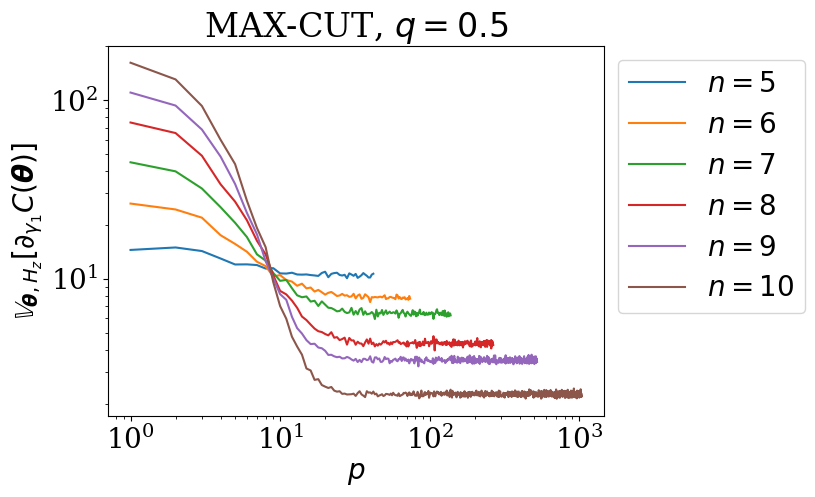

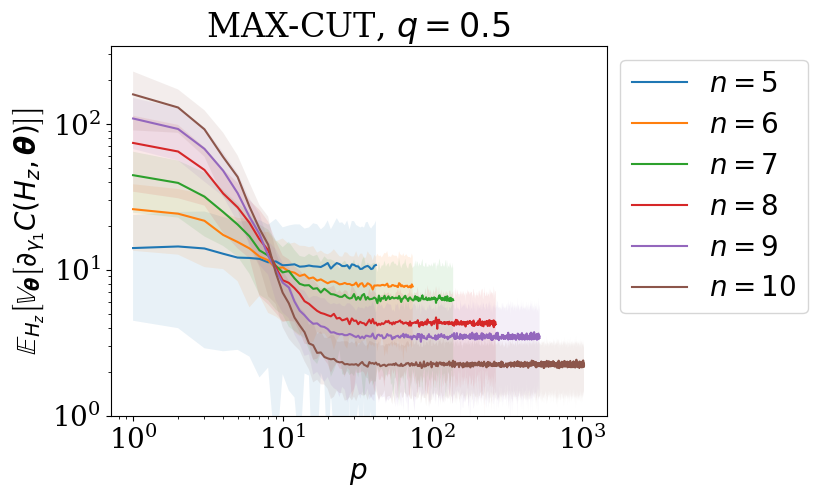

In [36]:
for n_i in range(len(n_list)):
    p_max = 2**(n_list[n_i] - 0) + 10
    plt.plot(arange(p_min, p_max + 1), np.var(grad_gamma_0_vals[n_i], axis=(0, 2))[:p_max], label=rf"$n={n_list[n_i]}$")
plt.xlabel(r"$p$")
plt.ylabel(r"$\mathbb{V}_{\boldsymbol{\theta}, H_z}[\partial_{\gamma_1} C(\boldsymbol{\theta})]$")
plt.title(rf"MAX-CUT, $q={prob}$")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

for n_i in range(len(n_list)):
    p_max = 2**(n_list[n_i] - 0) + 10
    x_axis = arange(p_min, p_max + 1)
    var_i = np.var(grad_gamma_0_vals[n_i], axis=2)[:p_max]
    var_i_mean = np.mean(var_i, axis=0)[:p_max]
    var_i_std = np.std(var_i, axis=0)[:p_max]
    plt.plot(x_axis, var_i_mean, label=rf"$n={n_list[n_i]}$")
    plt.fill_between(x_axis, var_i_mean - var_i_std, var_i_mean + var_i_std, alpha=0.1)
    # plt.errorbar(x_axis, var_i_mean[:p_max], yerr=var_i_std[:p_max])
plt.xlabel(r"$p$")
plt.ylabel(r"$\mathbb{E}_{H_z}\left[\mathbb{V}_{\boldsymbol{\theta}}\left[\partial_{\gamma_1} C (H_z, \boldsymbol{\theta})\right]\right]$")
plt.title(rf"MAX-CUT, $q={prob}$")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.ylim(ymin=1e0)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

In [29]:
path = "/home/investigator/Work/qaoa-qfi/Data/"
file_name = f"cut-bp-grad_gamma_0-n={n_list}-q={prob}-i={n_instances}-r={n_runs}-p=({p_min},{p_max})".replace(" ", "")

data_dict = {
    "n_list": n_list,
    "n_instances": n_instances,
    "n_runs": n_runs,
    "problem_name": "MAX-CUT", 
    "prob": prob,
    "p_min": p_min,
    "p_max": p_max,
    "note": "gamma_0 gradient component for MAX-CUT", 
    "QFIM_ranks": QFIM_ranks,
    "grad_gamma_0_vals": grad_gamma_0_vals,
    "H_diags": H_diags,
} 

# with open(path + file_name + ".dict", 'wb') as fp:
#     pickle.dump(data_dict, fp, protocol=pickle.HIGHEST_PROTOCOL)

## Plot

In [7]:
path = "/home/investigator/Work/qaoa-qfi/Data/"
file_name = "cut-bp-grad_gamma_0-n=[5,6,7,8,9,10]-q=0.5-i=50-r=100-p=(1,1034).dict"
with open(path + file_name, 'rb') as fp:
    data_dict_loaded = pickle.load(fp)

In [8]:
n_list = data_dict_loaded["n_list"]
n_instances = data_dict_loaded["n_instances"]
p_min = data_dict_loaded["p_min"]
p_max = data_dict_loaded["p_max"]
prob = data_dict_loaded["prob"]
p_cs = data_dict_loaded["QFIM_ranks"]/2
grad_gamma_0_vals = data_dict_loaded["grad_gamma_0_vals"]

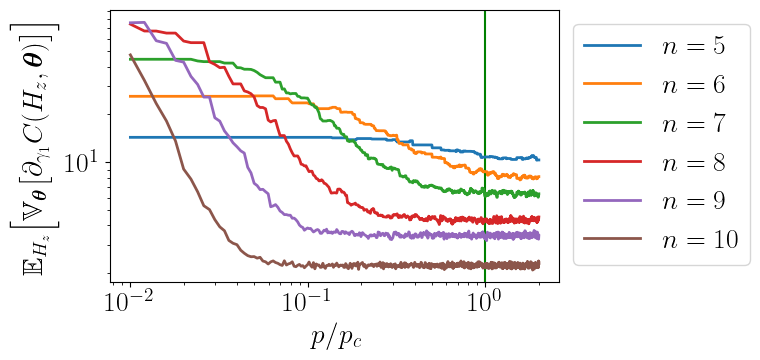

In [16]:
n_bins = 1000
p_c_bins = linspace(1e-2, 2, n_bins + 1)

mean_vars = []
mean_stds = []
for n_i in range(len(n_list)):
    p_max = 2**(n_list[n_i] - 0) + 10
    ppcs = np.stack([np.arange(1, p_max + 1)]*n_instances).T/p_cs[n_i]
    vars_i = np.var(grad_gamma_0_vals[n_i], axis=2)
    mean_vars_n = []
    mean_stds_n = []
    for bi in p_c_bins:
        inds = np.argmin(np.abs(ppcs - bi), axis=0)
        mean_vars_i = np.mean(vars_i[arange(n_instances), inds])
        mean_stds_i = np.std(vars_i[arange(n_instances), inds])
        mean_vars_n.append(mean_vars_i)
        mean_stds_n.append(mean_stds_i)
    mean_vars.append(mean_vars_n)
    mean_stds.append(mean_stds_n)
mean_vars = np.array(mean_vars)
mean_stds = np.array(mean_stds)

# mean_vars = []
# mean_stds = []
# for n_i in range(len(n_list)):
#     ppcs = np.stack([np.arange(1, p_max + 1)]*n_instances).T/p_cs[n_i]
#     vars_i = np.var(grad_gamma_0_vals[n_i], axis=2)
#     iterps = []
#     for pc_line, vars_line in zip(ppcs.T, vars_i):
#         iterps.append(np.interp(p_c_bins, pc_line, vars_line))
#     mean_vars.append(np.mean(iterps, axis=0))
#     mean_stds.append(np.std(iterps, axis=0))

plt.figure(figsize=(8, 4))
plt.axvline(1, color="green")
for n_i in range(len(n_list)):
    plt.plot(p_c_bins, mean_vars[n_i], linewidth=2, label=rf"$n={n_list[n_i]}$")
    # plt.fill_between(p_c_bins, mean_vars[n_i] - mean_stds[n_i], mean_vars[n_i] + mean_stds[n_i], alpha=0.1)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$p/p_c$")
plt.ylabel(r"$\mathbb{E}_{H_z}\Big[\mathbb{V}_{\boldsymbol{\theta}}\big[\partial_{\gamma_1} C (H_z, \boldsymbol{\theta})\big]\Big]$")
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig("/home/investigator/Work/qaoa-qfi/Results/" + "QFI_BP_CUT.pdf", transparent=True, bbox_inches='tight')
plt.show()